In [54]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
# Import SMOTE from imbalanced-learn
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder

In [55]:
data = pd.read_csv('Attrition.csv')

In [56]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

# OutLine
-----------
## 1. Data Preproccessing
###   1. Decreas N0. features
###   2. Encoding Categorical columns
###   3. Under sampling for Target --> To balance
--------------------------------------------------------
### 2. Train the Models
### 3. Compare between them
------------

# Test Feature Engineering ✅

In [59]:
Q1_MonthlyIncome = data['MonthlyIncome'].quantile(0.25)
Q3_MonthlyIncome = data['MonthlyIncome'].quantile(0.75)
IQR_MonthlyIncome = Q3_MonthlyIncome - Q1_MonthlyIncome

Q1_NumCompaniesWorked = data['NumCompaniesWorked'].quantile(0.25)
Q3_NumCompaniesWorked = data['NumCompaniesWorked'].quantile(0.75)
IQR_NumCompaniesWorked = Q3_NumCompaniesWorked - Q1_NumCompaniesWorked

Q1_PerformanceRating = data['PerformanceRating'].quantile(0.25)
Q3_PerformanceRating = data['PerformanceRating'].quantile(0.75)
IQR_PerformanceRating = Q3_PerformanceRating - Q1_PerformanceRating

Q1_StockOptionLevel = data['StockOptionLevel'].quantile(0.25)
Q3_StockOptionLevel = data['StockOptionLevel'].quantile(0.75)
IQR_StockOptionLevel = Q3_StockOptionLevel - Q1_StockOptionLevel

Q1_TotalWorkingYears = data['TotalWorkingYears'].quantile(0.25)
Q3_TotalWorkingYears = data['TotalWorkingYears'].quantile(0.75)
IQR_TotalWorkingYears = Q3_TotalWorkingYears - Q1_TotalWorkingYears

Q1_TrainingTimesLastYear = data['TrainingTimesLastYear'].quantile(0.25)
Q3_TrainingTimesLastYear = data['TrainingTimesLastYear'].quantile(0.75)
IQR_TrainingTimesLastYear = Q3_TrainingTimesLastYear - Q1_TrainingTimesLastYear

Q1_YearsAtCompany = data['YearsAtCompany'].quantile(0.25)
Q3_YearsAtCompany = data['YearsAtCompany'].quantile(0.75)
IQR_YearsAtCompany = Q3_YearsAtCompany - Q1_YearsAtCompany

Q1_YearsInCurrentRole = data['YearsInCurrentRole'].quantile(0.25)
Q3_YearsInCurrentRole = data['YearsInCurrentRole'].quantile(0.75)
IQR_YearsInCurrentRole = Q3_YearsInCurrentRole - Q1_YearsInCurrentRole

Q1_YearsSinceLastPromotion = data['YearsSinceLastPromotion'].quantile(0.25)
Q3_YearsSinceLastPromotion = data['YearsSinceLastPromotion'].quantile(0.75)
IQR_YearsSinceLastPromotion = Q3_YearsSinceLastPromotion - Q1_YearsSinceLastPromotion

Q1_YearsWithCurrManager = data['YearsWithCurrManager'].quantile(0.25)
Q3_YearsWithCurrManager = data['YearsWithCurrManager'].quantile(0.75)
IQR_YearsWithCurrManager = Q3_YearsWithCurrManager - Q1_YearsWithCurrManager


lower_MonthlyIncome = Q1_MonthlyIncome - 1.5 * IQR_MonthlyIncome
upper_MonthlyIncome = Q3_MonthlyIncome + 1.5 * IQR_MonthlyIncome

lower_NumCompaniesWorked = Q1_NumCompaniesWorked - 1.5 * IQR_NumCompaniesWorked
upper_NumCompaniesWorked = Q3_NumCompaniesWorked + 1.5 * IQR_NumCompaniesWorked

lower_PerformanceRating = Q1_PerformanceRating - 1.5 * IQR_PerformanceRating
upper_PerformanceRating = Q3_PerformanceRating + 1.5 * IQR_PerformanceRating

lower_StockOptionLevel = Q1_StockOptionLevel - 1.5 * IQR_StockOptionLevel
upper_StockOptionLevel = Q3_StockOptionLevel + 1.5 * IQR_StockOptionLevel

lower_TotalWorkingYears = Q1_TotalWorkingYears - 1.5 * IQR_TotalWorkingYears
upper_TotalWorkingYears = Q3_TotalWorkingYears + 1.5 * IQR_TotalWorkingYears

lower_TrainingTimesLastYear = Q1_TrainingTimesLastYear - 1.5 * IQR_TrainingTimesLastYear
upper_TrainingTimesLastYear = Q3_TrainingTimesLastYear + 1.5 * IQR_TrainingTimesLastYear

lower_YearsAtCompany = Q1_YearsAtCompany - 1.5 * IQR_YearsAtCompany
upper_YearsAtCompany = Q3_YearsAtCompany + 1.5 * IQR_YearsAtCompany

lower_YearsInCurrentRole = Q1_YearsInCurrentRole - 1.5 * IQR_YearsInCurrentRole
upper_YearsInCurrentRole = Q3_YearsInCurrentRole + 1.5 * IQR_YearsInCurrentRole

lower_YearsSinceLastPromotion = Q1_YearsSinceLastPromotion - 1.5 * IQR_YearsSinceLastPromotion
upper_YearsSinceLastPromotion = Q3_YearsSinceLastPromotion + 1.5 * IQR_YearsSinceLastPromotion

lower_YearsWithCurrManager = Q1_YearsWithCurrManager - 1.5 * IQR_YearsWithCurrManager
upper_YearsWithCurrManager = Q3_YearsWithCurrManager + 1.5 * IQR_YearsWithCurrManager





data['MonthlyIncome'] = data['MonthlyIncome'].clip(lower=lower_MonthlyIncome, upper=upper_MonthlyIncome)

data['NumCompaniesWorked'] = data['NumCompaniesWorked'].clip(
    lower=lower_NumCompaniesWorked,
    upper=upper_NumCompaniesWorked
)

data['PerformanceRating'] = data['PerformanceRating'].clip(
    lower=lower_PerformanceRating,
    upper=upper_PerformanceRating
)

data['StockOptionLevel'] = data['StockOptionLevel'].clip(
    lower=lower_StockOptionLevel,
    upper=upper_StockOptionLevel
)

data['TotalWorkingYears'] = data['TotalWorkingYears'].clip(
    lower=lower_TotalWorkingYears,
    upper=upper_TotalWorkingYears
)

data['TrainingTimesLastYear'] = data['TrainingTimesLastYear'].clip(
    lower=lower_TrainingTimesLastYear,
    upper=upper_TrainingTimesLastYear
)

data['YearsAtCompany'] = data['YearsAtCompany'].clip(
    lower=lower_YearsAtCompany,
    upper=upper_YearsAtCompany
)

data['YearsInCurrentRole'] = data['YearsInCurrentRole'].clip(
    lower=lower_YearsInCurrentRole,
    upper=upper_YearsInCurrentRole
)

data['YearsSinceLastPromotion'] = data['YearsSinceLastPromotion'].clip(
    lower=lower_YearsSinceLastPromotion,
    upper=upper_YearsSinceLastPromotion
)

data['YearsWithCurrManager'] = data['YearsWithCurrManager'].clip(
    lower=lower_YearsWithCurrManager,
    upper=upper_YearsWithCurrManager
)


In [34]:
data['Total_Satisfaction'] = (data['JobSatisfaction'] + data['EnvironmentSatisfaction'] + data['RelationshipSatisfaction']) / 3
data['Income_to_Experience'] = data['MonthlyIncome'] / (data['TotalWorkingYears'] + 1)
data['Job_Hopper_Index'] = data['NumCompaniesWorked'] / (data['TotalWorkingYears'] + 1)

In [35]:
features_to_keep = [
    'Age',
    'OverTime',
    'BusinessTravel',
    'TotalWorkingYears',
    'MonthlyIncome',
    'StockOptionLevel',
    'Total_Satisfaction',
    'Income_to_Experience',
    'Job_Hopper_Index'
]
x = data[features_to_keep].copy()
y = data['Attrition'].map({"Yes":1, "No":0})

In [60]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   1470 non-null   int64  
 1   OverTime              1470 non-null   int64  
 2   BusinessTravel        1470 non-null   int64  
 3   TotalWorkingYears     1470 non-null   int64  
 4   MonthlyIncome         1470 non-null   int64  
 5   StockOptionLevel      1470 non-null   int64  
 6   Total_Satisfaction    1470 non-null   float64
 7   Income_to_Experience  1470 non-null   float64
 8   Job_Hopper_Index      1470 non-null   float64
dtypes: float64(3), int64(6)
memory usage: 103.5 KB


 ### Encoding Step

In [61]:
OverTime_encoder = LabelEncoder()
BusinessTravel_encoder = LabelEncoder()
x['OverTime'] = OverTime_encoder.fit_transform(x['OverTime'])
x['BusinessTravel'] = BusinessTravel_encoder.fit_transform(x['BusinessTravel'])


In [62]:
import joblib

joblib.dump(OverTime_encoder,'overTime_encoder.pkl')
joblib.dump(BusinessTravel_encoder,'business_encoder.pkl')


['business_encoder.pkl']

In [63]:
y.value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

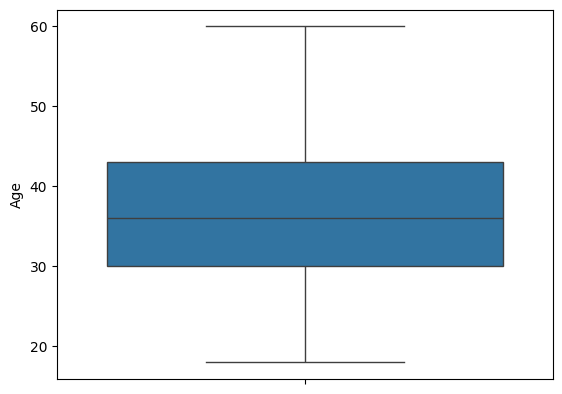

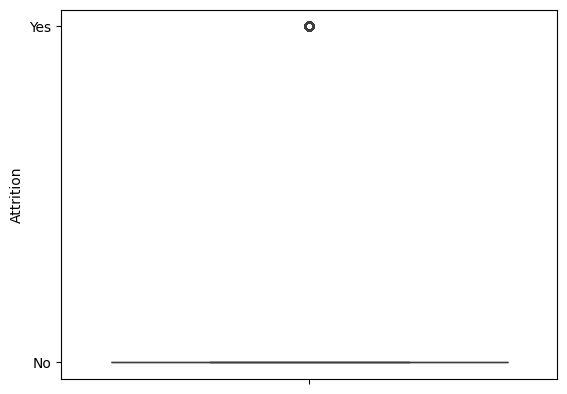

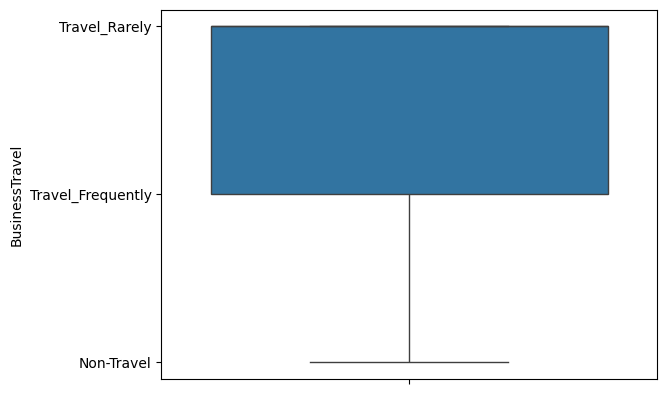

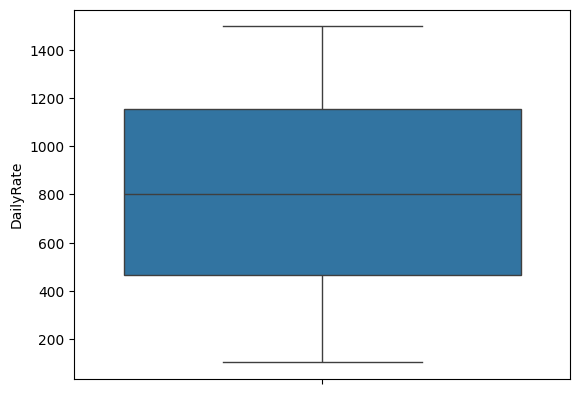

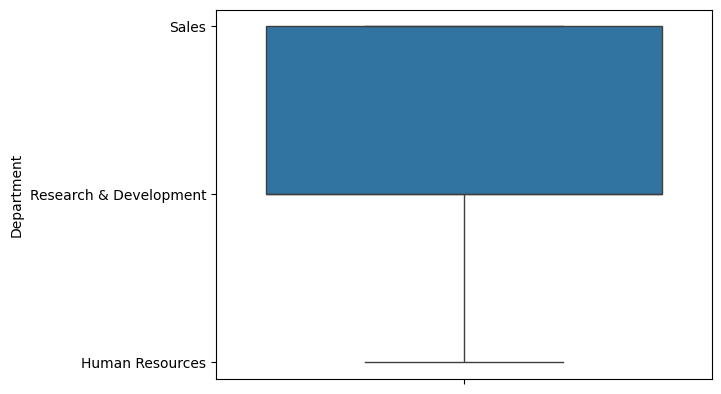

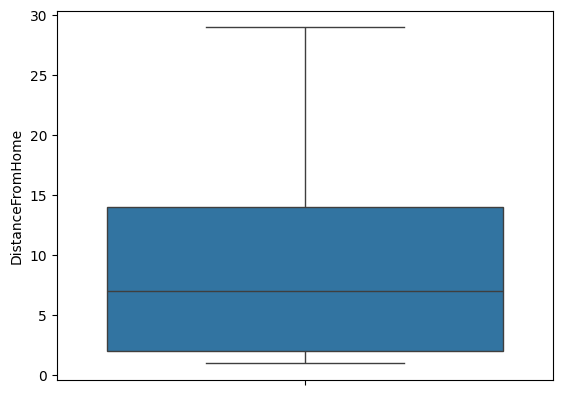

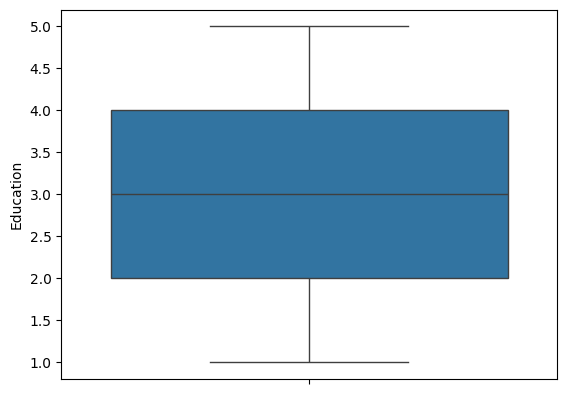

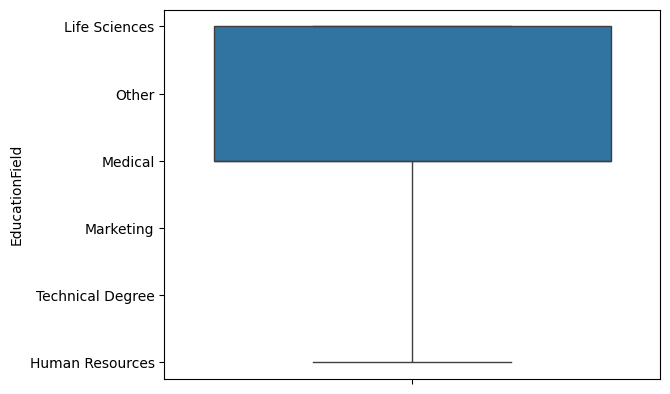

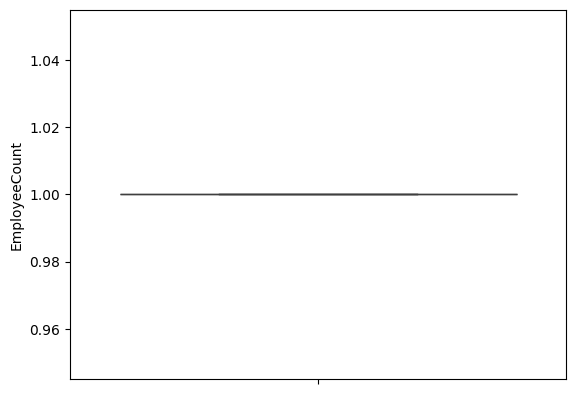

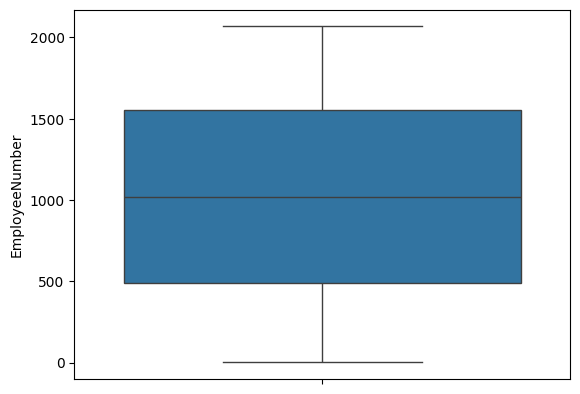

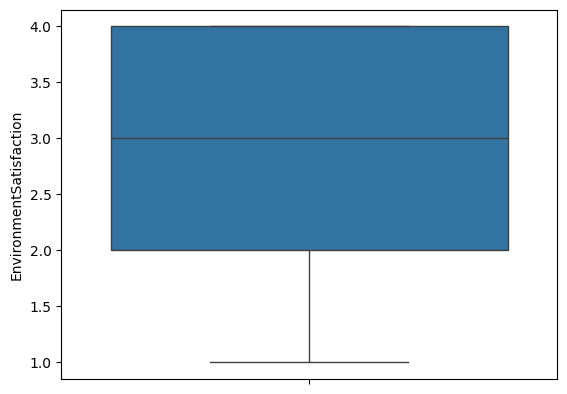

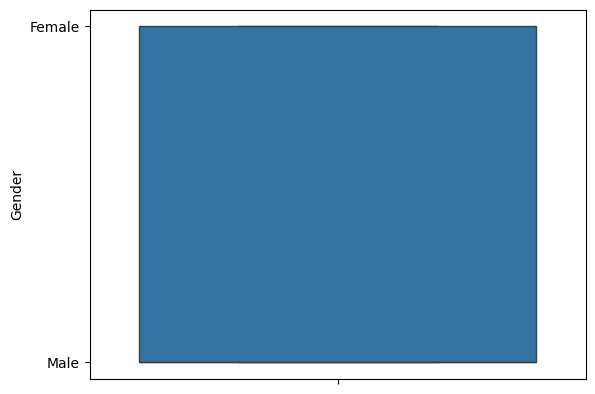

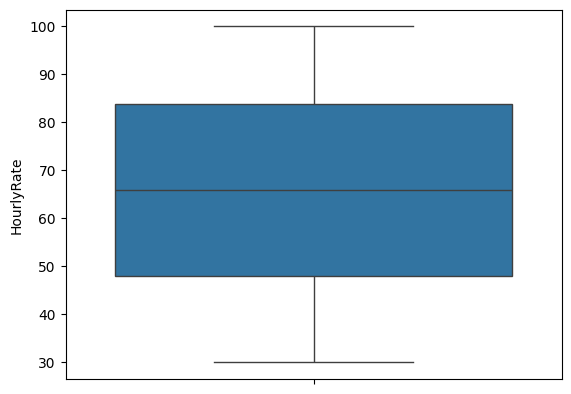

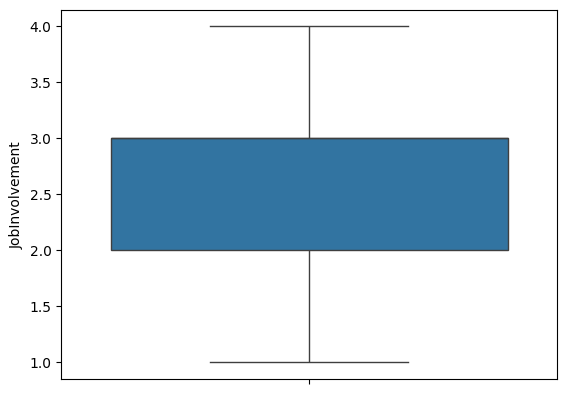

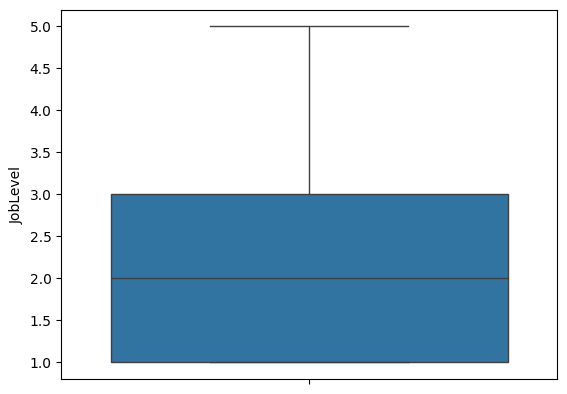

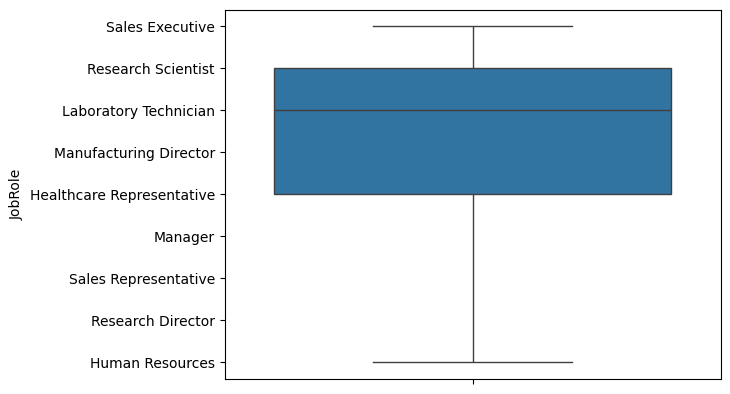

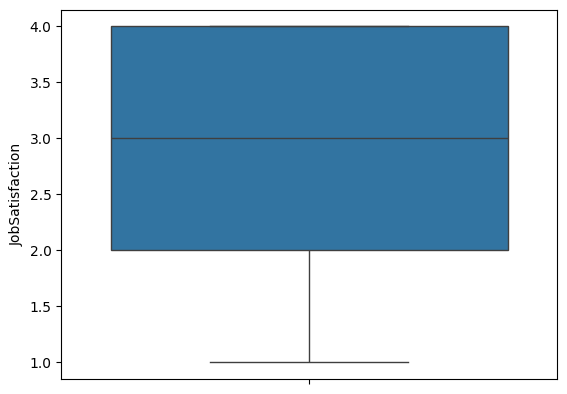

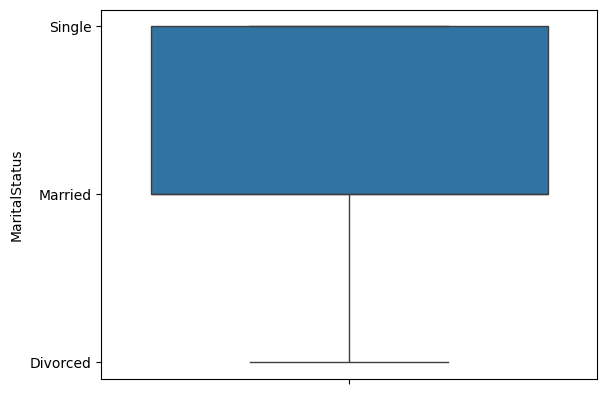

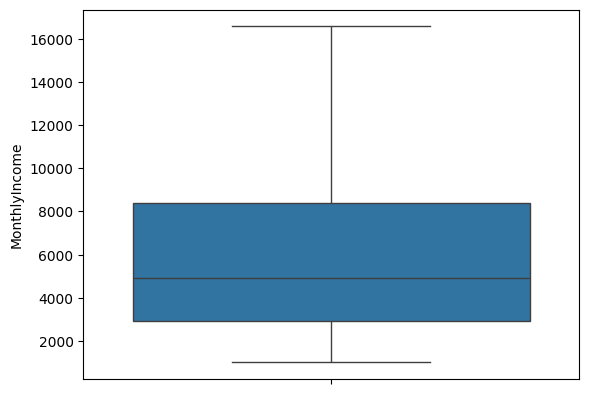

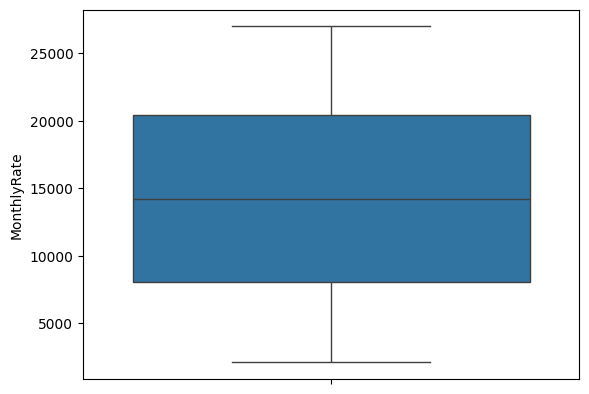

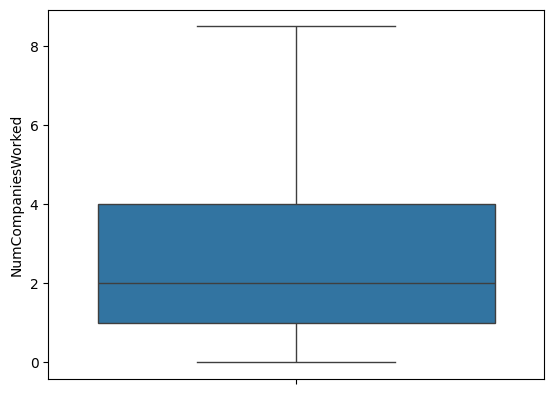

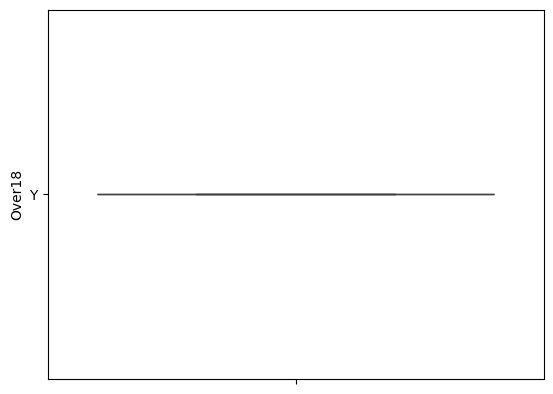

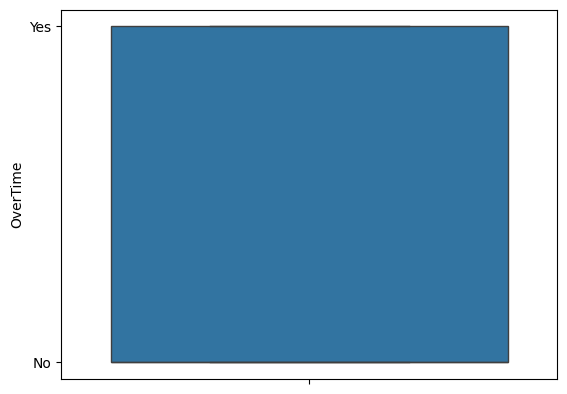

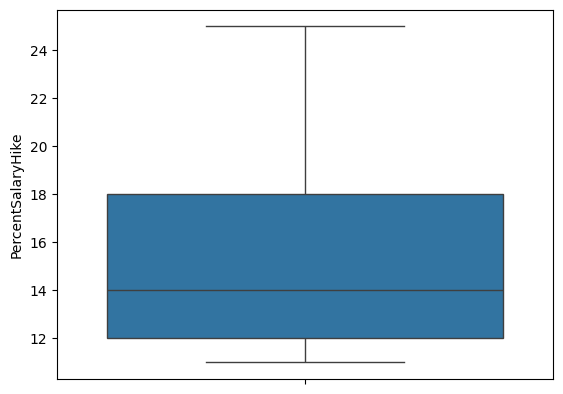

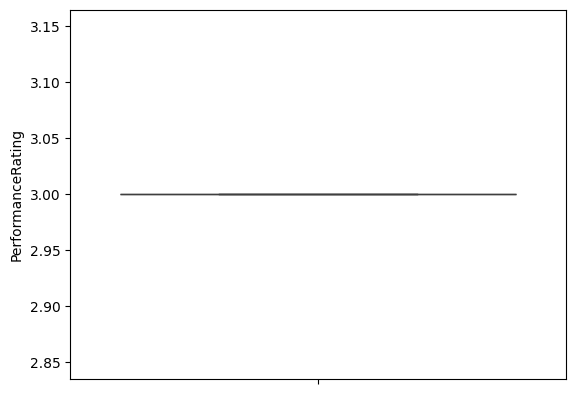

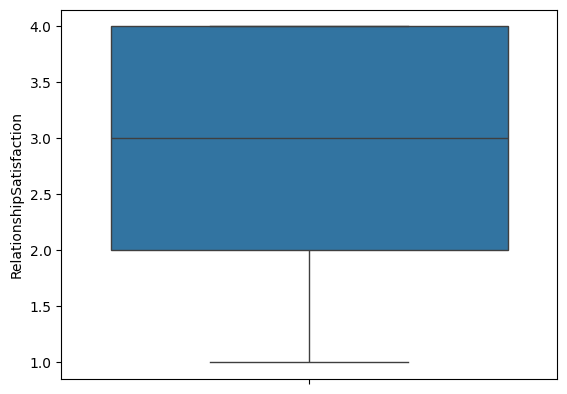

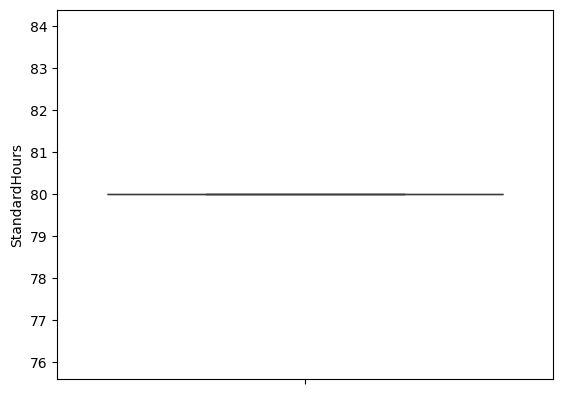

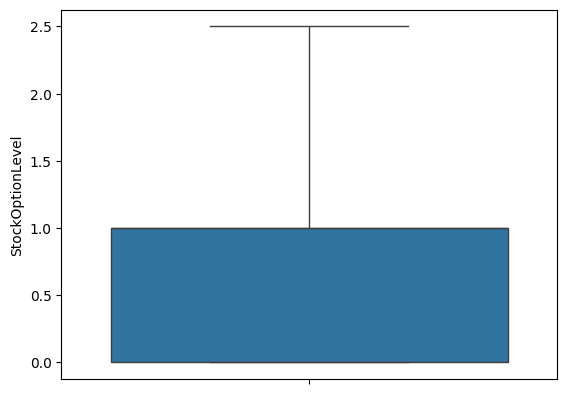

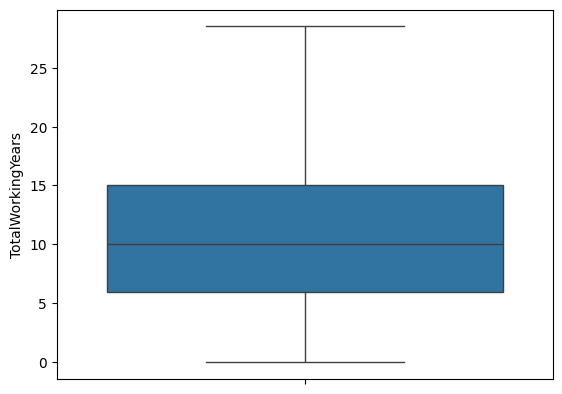

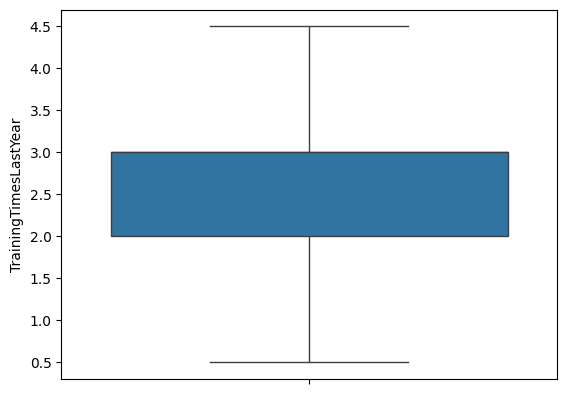

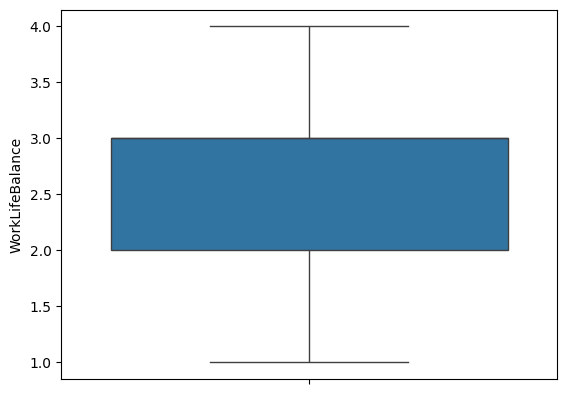

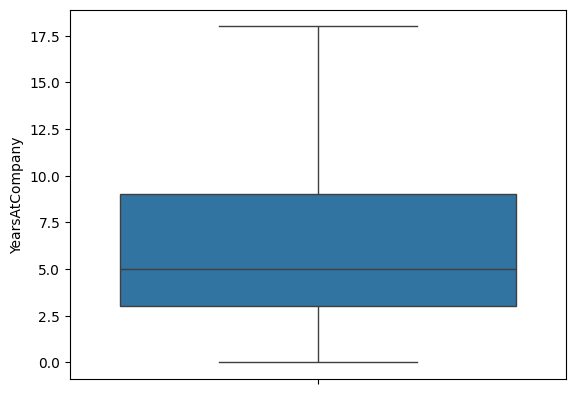

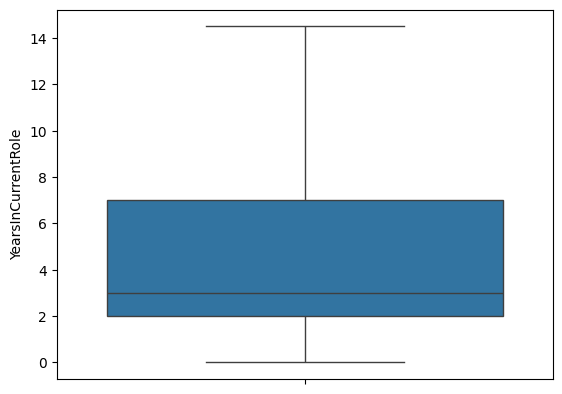

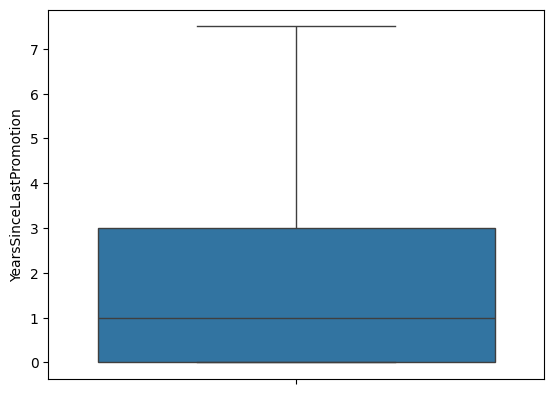

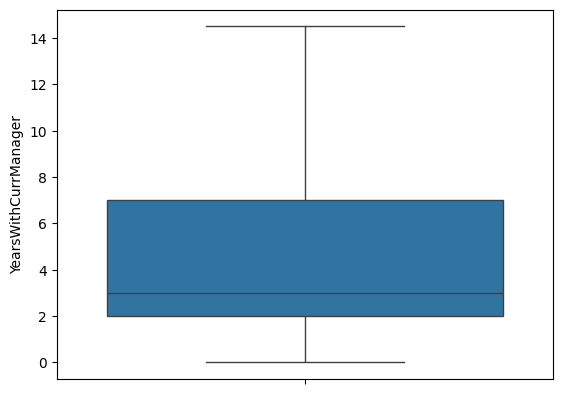

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt
for col in data.columns:
    sns.boxplot(data[col])
    plt.show()
    

In [65]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

###  OverSampling Using SMOTE

In [66]:
over_sampler = SMOTE(random_state=42)
x_train_resample, y_train_resample = over_sampler.fit_resample(x_train, y_train)

## Random Forest Model

In [67]:
model_1= RandomForestClassifier(n_estimators=300, class_weight='balanced',bootstrap=True, random_state=42)
model_1.fit(x_train_resample, y_train_resample)
predict_1 = model_1.predict(x_test)
print(classification_report(y_test, predict_1))

              precision    recall  f1-score   support

           0       0.90      0.91      0.90       255
           1       0.36      0.33      0.35        39

    accuracy                           0.83       294
   macro avg       0.63      0.62      0.63       294
weighted avg       0.83      0.83      0.83       294



## Logistic Regresiion model

In [68]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [69]:
x_train_resample_1, y_train_resample_1 = under_sampler.fit_resample(x_train_scaled, y_train)


In [70]:
model_2 = LogisticRegression( random_state=42)
model_2.fit(x_train_resample_1, y_train_resample_1)
predict_2 = model_2.predict(x_test_scaled)
print(classification_report(y_test, predict_2))

              precision    recall  f1-score   support

           0       0.93      0.73      0.82       255
           1       0.27      0.64      0.38        39

    accuracy                           0.72       294
   macro avg       0.60      0.69      0.60       294
weighted avg       0.84      0.72      0.76       294



## SVM Model

In [71]:
model_3 = SVC(
    C=1,
    class_weight='balanced',
    random_state=42
    )
model_3.fit(x_train_resample_1, y_train_resample_1)
predict_3 = model_3.predict(x_test_scaled)
print(classification_report(y_test, predict_3))

              precision    recall  f1-score   support

           0       0.93      0.81      0.87       255
           1       0.33      0.62      0.43        39

    accuracy                           0.79       294
   macro avg       0.63      0.71      0.65       294
weighted avg       0.85      0.79      0.81       294



## KNN model

In [72]:
model_4 = KNeighborsClassifier(
    n_neighbors=3,
    weights='distance',
)
model_4.fit(x_train_resample_1, y_train_resample_1)
predict_4 = model_4.predict(x_test_scaled)
print(classification_report(y_test, predict_4))

              precision    recall  f1-score   support

           0       0.92      0.78      0.84       255
           1       0.27      0.54      0.36        39

    accuracy                           0.75       294
   macro avg       0.59      0.66      0.60       294
weighted avg       0.83      0.75      0.78       294



In [73]:
from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

metrics = {
    'Model': ['Random Forest', 'Logistic Regression', 'SVM', 'KNN'],
    'Accuracy': [
        accuracy_score(y_test, predict_1),
        accuracy_score(y_test, predict_2),
        accuracy_score(y_test, predict_3),
        accuracy_score(y_test, predict_4)
    ],
    'F1-Score (Class 1)': [
        f1_score(y_test, predict_1, pos_label=1),
        f1_score(y_test, predict_2, pos_label=1),
        f1_score(y_test, predict_3, pos_label=1),
        f1_score(y_test, predict_4, pos_label=1)
    ]
}

metrics_df = pd.DataFrame(metrics)

print("Model Performance Comparison:")
display(metrics_df)


Model Performance Comparison:


,Model,Accuracy,F1-Score (Class 1)
0,Random Forest,0.833333,0.346667
1,Logistic Regression,0.721088,0.378788
2,SVM,0.785714,0.432432
3,KNN,0.748299,0.362069


C:\Users\user\AppData\Local\Temp\ipykernel_16760\635331792.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=metrics_df, ax=axes[0], palette='rainbow')
C:\Users\user\AppData\Local\Temp\ipykernel_16760\635331792.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='F1-Score (Class 1)', data=metrics_df, ax=axes[1], palette='rainbow')


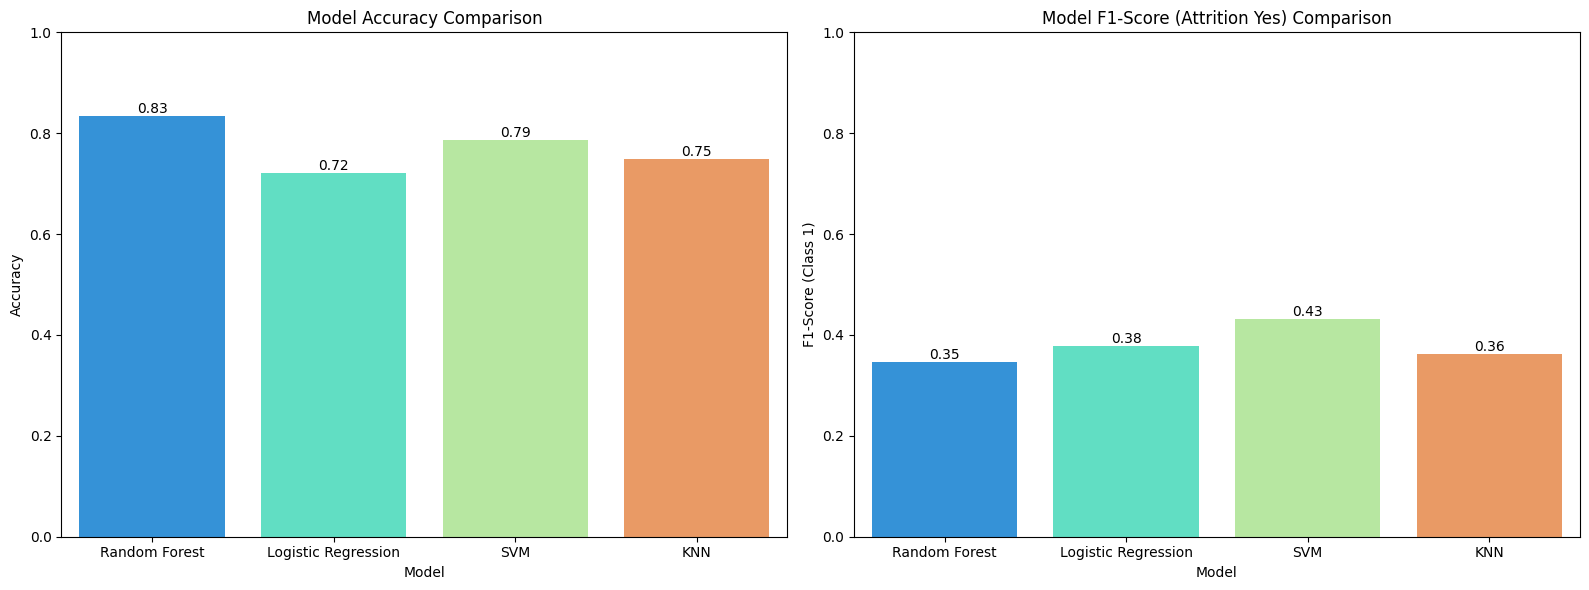

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='Model', y='Accuracy', data=metrics_df, ax=axes[0], palette='rainbow')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
for index, row in metrics_df.iterrows():
    axes[0].text(index, row['Accuracy'], round(row['Accuracy'], 2), color='black', ha="center", va='bottom')

sns.barplot(x='Model', y='F1-Score (Class 1)', data=metrics_df, ax=axes[1], palette='rainbow')
axes[1].set_title('Model F1-Score (Attrition Yes) Comparison')
axes[1].set_ylabel('F1-Score (Class 1)')
axes[1].set_ylim(0, 1)
for index, row in metrics_df.iterrows():
    axes[1].text(index, row['F1-Score (Class 1)'], round(row['F1-Score (Class 1)'], 2), color='black', ha="center", va='bottom')

plt.tight_layout()
plt.show()

In [80]:
joblib.dump(model_3,'attrition_model.pkl')

['attrition_model.pkl']

In [78]:
x.columns

Index(['Age', 'OverTime', 'BusinessTravel', 'TotalWorkingYears',
       'MonthlyIncome', 'StockOptionLevel', 'Total_Satisfaction',
       'Income_to_Experience', 'Job_Hopper_Index'],
      dtype='object')

In [79]:
x

,Age,OverTime,BusinessTravel,TotalWorkingYears,MonthlyIncome,StockOptionLevel,Total_Satisfaction,Income_to_Experience,Job_Hopper_Index
0,41,1,2,8,5993,0,2.333333,665.888889,0.888889
1,49,0,1,10,5130,1,3.000000,466.363636,0.090909
2,37,1,2,7,2090,0,3.000000,261.250000,0.750000
3,33,1,1,8,2909,0,3.333333,323.222222,0.111111
4,27,0,2,6,3468,1,2.333333,495.428571,1.285714
...,...,...,...,...,...,...,...,...,...
1465,36,0,1,17,2571,1,3.333333,142.833333,0.222222
1466,39,0,2,9,9991,1,2.000000,999.100000,0.400000
1467,27,1,2,6,6142,1,2.000000,877.428571,0.142857
1468,49,0,1,17,5390,0,3.333333,299.444444,0.111111
